# Datasets

In [ ]:
# Bu tayyor dataset'lar to'plami (MNIST, CIFAR10 va boshqalar). Ularni o'zing papkaga saralab chiqishimiz shart emas, bitta buyruq bilan yuklab olinadi.

# Mashhur dataset'lar
# MNIST - 28 x 28, grayscale - qo'lyozma raqamlar (0 dan 9 gacha) - 1o ta class

In [2]:
from torchvision import datasets, transforms

train_data = datasets.MNIST(
    root="data",                      # "data" folderga saqlanadi
    train=True,                       # True = train qismi, False = test qismi
    download=True,                    # yo'q bo'lsa yuklab oladi
    transform=transforms.ToTensor(),  # PIL rasm -> tensor, [0, 1]
)



In [8]:
print(len(train_data))        # length of data
print(train_data.classes)     # class lar sone

x, y = train_data[0]          # 0-chi namuna
print(x.shape)                # [C, H, W] - grayscale - c = 1
print(x.min(), x.max())       # 0.0 ... 1.0
print(y)                      # 5 (label, oddiy butun son)

60000
['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']
torch.Size([1, 28, 28])
tensor(0.) tensor(1.)
5


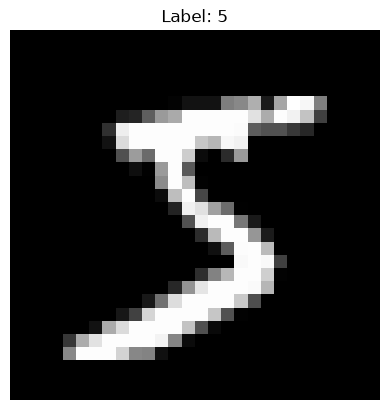

In [9]:
import matplotlib.pyplot as plt

plt.imshow(x.squeeze(), cmap="gray")   # [1,28,28] -> [28,28]
plt.title(f"Label: {y}")
plt.axis("off")
plt.show()

# Pretrained Model

In [ ]:
# Pretrained model = boshqa birov katta datasetda (masalan ImageNet: million atrofida rasm, 1000 sinf) allaqachon o'qitib bo'lgan tayyor model. Uning o'rganilgan sonlari weights (og'irliklar) deyiladi.

# Noldan o'qitish uchun minglab rasm va kuchli GPU kerak. Pretrained da tayyor.


In [10]:
from torchvision.models import resnet50, ResNet50_Weights

weights = ResNet50_Weights.DEFAULT # ResNet50 da DEFAULT eng yangi tayyorlangan weights
model = resnet50(weights=weights) # weights=None degani tasodifiy boshlang'ich weights, ya'ni o'qitilmagan model.


0.6%

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /Users/asadbek/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100.0%


In [12]:

# Pretrained model qanday preprocessing bilan o'qitilgan bo'lsa, aynan shunday berilishi shart. Buni qo'lda yozmaymiz: har bir weights o'zining inference transformlarini ham taqdim etadi

preprocess = weights.transforms()

preprocess

ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [14]:
import torch
from PIL import Image
from torchvision.models import resnet50, ResNet50_Weights

weights = ResNet50_Weights.DEFAULT
model = resnet50(weights=weights)

model.eval()                                   # inference rejimi

preprocess = weights.transforms()

img = Image.open("dataset/train/phones/iphone.jpg").convert("RGB")
x = preprocess(img).unsqueeze(0)               # [3,224,224] -> [1,3,224,224]

with torch.no_grad():                          # gradient hisoblamaymiz
    logits = model(x)                          # [1, 1000]
    probs = logits.softmax(dim=1)              # ehtimollarga aylantirish

top5 = probs[0].topk(5)
categories = weights.meta["categories"]
for p, idx in zip(top5.values, top5.indices):
    print(f"{categories[idx]}: {p:.1%}")

cellular telephone: 30.5%
iPod: 11.8%
hand-held computer: 4.7%
radio: 1.0%
remote control: 0.8%


In [17]:
len(categories)

1000

In [18]:
categories

['tench',
 'goldfish',
 'great white shark',
 'tiger shark',
 'hammerhead',
 'electric ray',
 'stingray',
 'cock',
 'hen',
 'ostrich',
 'brambling',
 'goldfinch',
 'house finch',
 'junco',
 'indigo bunting',
 'robin',
 'bulbul',
 'jay',
 'magpie',
 'chickadee',
 'water ouzel',
 'kite',
 'bald eagle',
 'vulture',
 'great grey owl',
 'European fire salamander',
 'common newt',
 'eft',
 'spotted salamander',
 'axolotl',
 'bullfrog',
 'tree frog',
 'tailed frog',
 'loggerhead',
 'leatherback turtle',
 'mud turtle',
 'terrapin',
 'box turtle',
 'banded gecko',
 'common iguana',
 'American chameleon',
 'whiptail',
 'agama',
 'frilled lizard',
 'alligator lizard',
 'Gila monster',
 'green lizard',
 'African chameleon',
 'Komodo dragon',
 'African crocodile',
 'American alligator',
 'triceratops',
 'thunder snake',
 'ringneck snake',
 'hognose snake',
 'green snake',
 'king snake',
 'garter snake',
 'water snake',
 'vine snake',
 'night snake',
 'boa constrictor',
 'rock python',
 'Indian cobr

# Torchvision

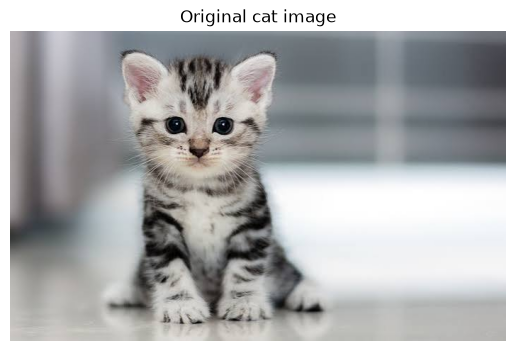

(700, 438)


In [26]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("cat.jpeg")


def show_img(image, title):
    plt.imshow(image)
    plt.title(title)
    plt.axis("off")
    plt.show()

show_img(img, "Original cat image")
print(img.size)

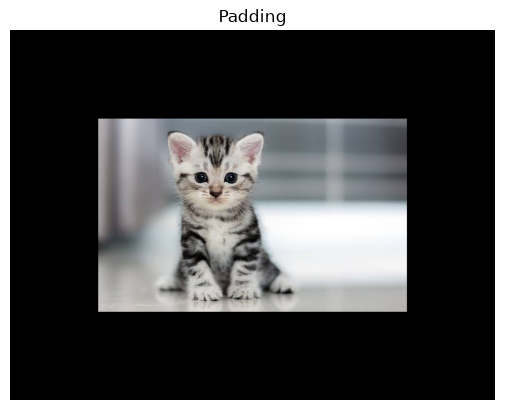

(1100, 838)


In [27]:
from torchvision import transforms

# Padding = rasm chetlariga bo'sh joy (ramka) qo'shadi.

pad = transforms.Pad(200) # har tomonga 200 pixeldan qo'shadi
# H = H + 2 * 200 chunki tepa va pastdan 200 dan qoshilyabdi
# W = W + 2 * 200 bu ham shunday
# (700, 438) edi => after padding (700 + 400, 438 + 400) - (1100, 838)
new_image = pad(img)

show_img(new_image, "Padding")

print(new_image.size)


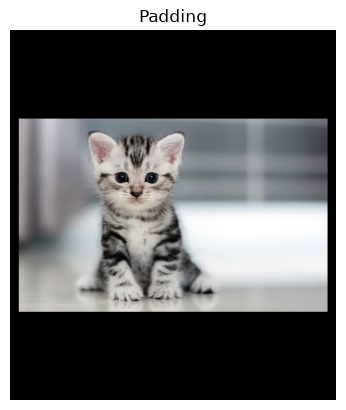

In [33]:
# Pad((x, y)) - x => left, right, y => top, bottom
pad = transforms.Pad((20, 200)) 
new_image = pad(img)

show_img(new_image, "Padding")

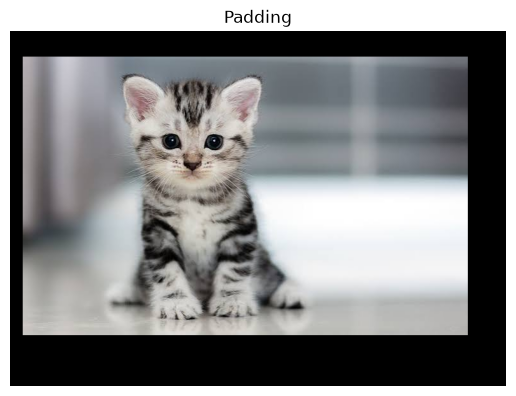

In [ ]:
# Pad((x, y, z, f)) - x => left, y => top, z => right, f => bottom
pad = transforms.Pad((20, 40, 60, 80)) 
new_image = pad(img)


show_img(new_image, "Padding")

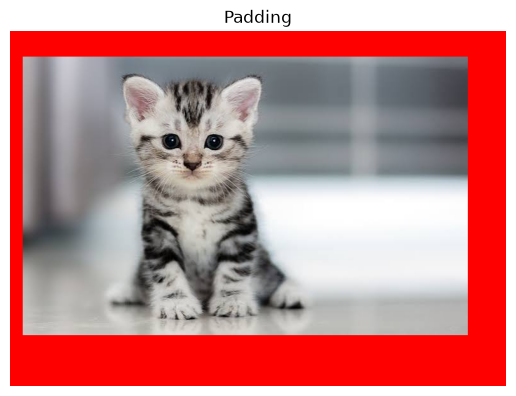

In [ ]:
# default => 0 ya'ni qora
# fill = 255 => paddinglarni oq rang bilan toldiradi
# fill = 0 => paddinglarni qora rang bilan toldiradi
# fill=(R, G, B) => RBG (faqat sonlada beramiz)
# fill ga berilgan qiymatlar padding_mode="constant" holatda ishlaydi

pad = transforms.Pad((20, 40, 60, 80), fill=(255, 0, 0)) 
new_image = pad(img)

show_img(new_image, "Padding")

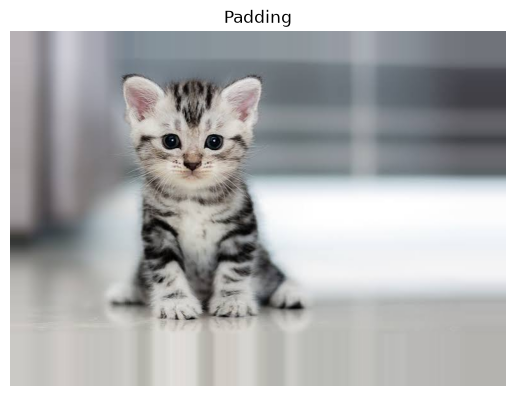

In [ ]:
pad = transforms.Pad((20, 40, 60, 80), padding_mode="edge")
# Rasmni chetidagi qiymatni takkorlaydi 
new_image = pad(img)

show_img(new_image, "Padding")

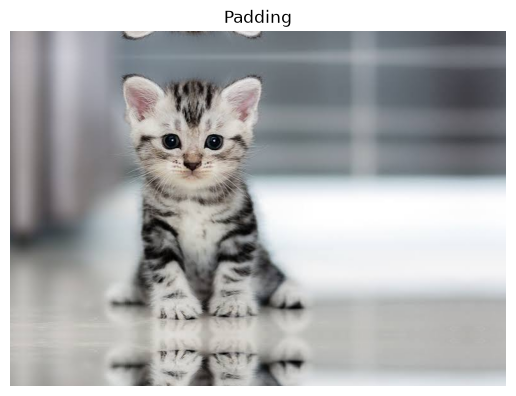

In [ ]:
pad = transforms.Pad((20, 40, 60, 80), padding_mode="reflect")
# chekkada oxirgi qiymatni takrorlamasdan tasvirni aks ettiradi
# eng chetidagi qiymat olinmaydi
new_image = pad(img)

show_img(new_image, "Padding")

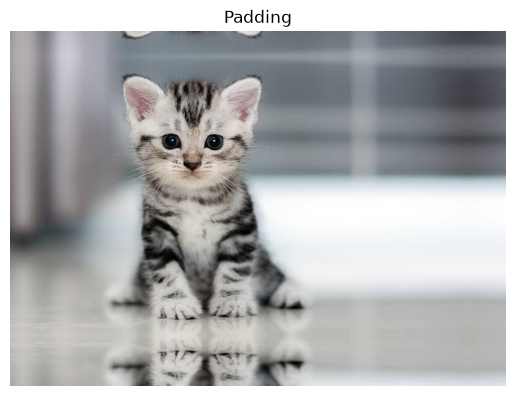

In [ ]:
pad = transforms.Pad((20, 40, 60, 80), padding_mode="symmetric")
# chekkada oxirgi qiymatni takrorlaydigan tasvir aks ettiriladi
# eng chetidagi qiymat ham olinadi
new_image = pad(img)

show_img(new_image, "Padding")